In [1]:
import kagglehub
import os
import pandas as pd
import glob
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


C:\Users\naman yadav\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahuldogra/top5000youtubechannels")

print("Path to dataset files:", path)

100%|██████████| 128k/128k [00:00<00:00, 218kB/s]

Extracting files...
Path to dataset files: C:\Users\naman yadav\.cache\kagglehub\datasets\rahuldogra\top5000youtubechannels\versions\1


In [4]:
# List files in the path to find the correct CSV file
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
print("Available CSV files:", csv_files)

# Read the CSV file
df = pd.read_csv(csv_files[0])

Available CSV files: ['C:\\Users\\naman yadav\\.cache\\kagglehub\\datasets\\rahuldogra\\top5000youtubechannels\\versions\\1\\top-5000-youtube-channels.csv']


In [5]:
df.shape

(5000, 6)

In [8]:
df.describe()

,Video views
count,5.000000e+03
mean,1.071449e+09
std,2.003844e+09
min,7.500000e+01
25%,1.862329e+08
50%,4.820548e+08
75%,1.124368e+09
max,4.754884e+10


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Rank           5000 non-null   str  
 1   Grade          5000 non-null   str  
 2   Channel name   5000 non-null   str  
 3   Video Uploads  5000 non-null   str  
 4   Subscribers    5000 non-null   str  
 5   Video views    5000 non-null   int64
dtypes: int64(1), str(5)
memory usage: 234.5 KB


In [10]:
df.head()

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
0,1st,A++,Zee TV,82757,18752951,20869786591
1,2nd,A++,T-Series,12661,61196302,47548839843
2,3rd,A++,Cocomelon - Nursery Rhymes,373,19238251,9793305082
3,4th,A++,SET India,27323,31180559,22675948293
4,5th,A++,WWE,36756,32852346,26273668433


In [11]:
df.tail()

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
4995,"4,996th",B+,Uras Benlioğlu,706,2072942,441202795
4996,"4,997th",B+,HI-TECH MUSIC LTD,797,1055091,377331722
4997,"4,998th",B+,Mastersaint,110,3265735,311758426
4998,"4,999th",B+,Bruce McIntosh,3475,32990,14563764
4999,"5,000th",B+,SehatAQUA,254,21172,73312511


In [12]:
df['Rank'].isnull().sum()

np.int64(0)

In [13]:
df['Rank'].duplicated().sum()

np.int64(0)

In [15]:
df['Rank'].value_counts().sum()

np.int64(5000)

In [16]:
df['Grade'].isnull().sum()  

np.int64(0)

In [17]:
df['Grade'].value_counts().sum()    

np.int64(5000)

<Figure size 600x600 with 0 Axes>

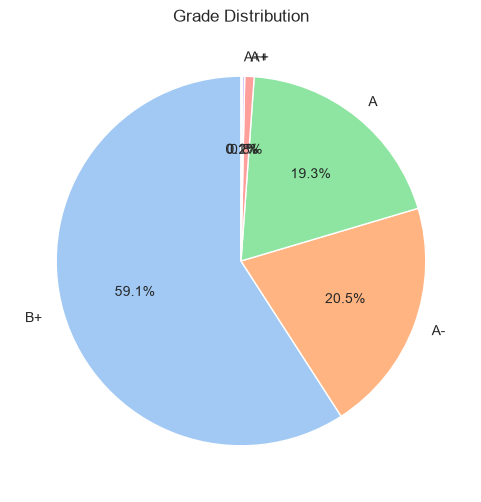

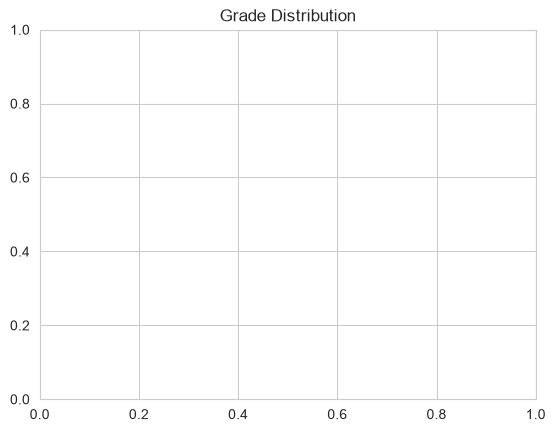

In [22]:
sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
grade_counts = df['Grade'].value_counts()
sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(grade_counts.values, labels=grade_counts.index, autopct='%1.1f%%',
    startangle=90, colors=sns.color_palette("pastel"))
plt.title('Grade Distribution')
plt.show()
plt.title('Grade Distribution')
plt.show()

In [35]:
df['Subscribers'].value_counts()

Subscribers
92158       2
666561      2
18752951    1
61196302    1
19238251    1
           ..
2072942     1
1055091     1
3265735     1
32990       1
21172       1
Name: count, Length: 4611, dtype: int64

In [34]:
import numpy as np

# Replace '--' with NaN
df['Subscribers'] = df['Subscribers'].replace('--', np.nan)




In [36]:
df['Subscribers'].value_counts()

Subscribers
92158       2
666561      2
18752951    1
61196302    1
19238251    1
           ..
2072942     1
1055091     1
3265735     1
32990       1
21172       1
Name: count, Length: 4611, dtype: int64

In [37]:
df['Subscribers'] = df['Subscribers'].dropna()

In [39]:
import numpy as np

# Step 1: Replace '--' with NaN
df['Subscribers'] = df['Subscribers'].replace('--', np.nan)

# Step 2: Drop rows where Subscribers is NaN
df = df.dropna(subset=['Subscribers'])


In [40]:
df.columns

Index(['Rank', 'Grade', 'Channel name', 'Video Uploads', 'Subscribers',
       'Video views'],
      dtype='str')

In [42]:
df.isnull().sum()

Rank             0
Grade            0
Channel name     0
Video Uploads    0
Subscribers      0
Video views      0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df['Video Uploads'].value_counts()

Video Uploads
26      16
20      16
30      14
8       14
36      14
        ..
9876     1
7299     1
1735     1
706      1
3475     1
Name: count, Length: 2216, dtype: int64

In [45]:
df['Video Uploads'].duplicated().sum()

np.int64(2397)

In [46]:
df['Video Uploads'].isnull().sum()

np.int64(0)

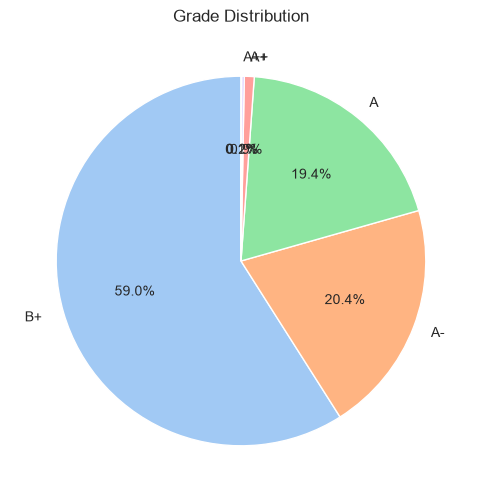

In [47]:

grade_counts = df['Grade'].value_counts()

sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette("pastel"))
plt.title('Grade Distribution')
plt.show()


C:\Users\naman yadav\AppData\Local\Temp\ipykernel_51268\2116125412.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Grade', y='Subscribers', data=df, estimator='mean', palette='pastel')


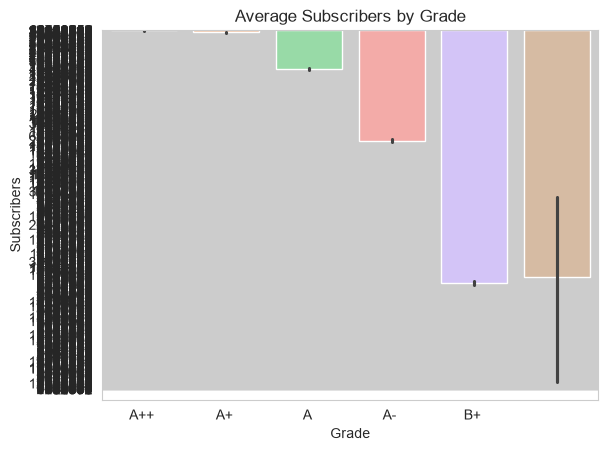

In [48]:
sns.barplot(x='Grade', y='Subscribers', data=df, estimator='mean', palette='pastel')
plt.title('Average Subscribers by Grade')
plt.show()


C:\Users\naman yadav\AppData\Local\Temp\ipykernel_51268\470306087.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Subscribers', y='Channel name', data=top_channels, palette='muted')


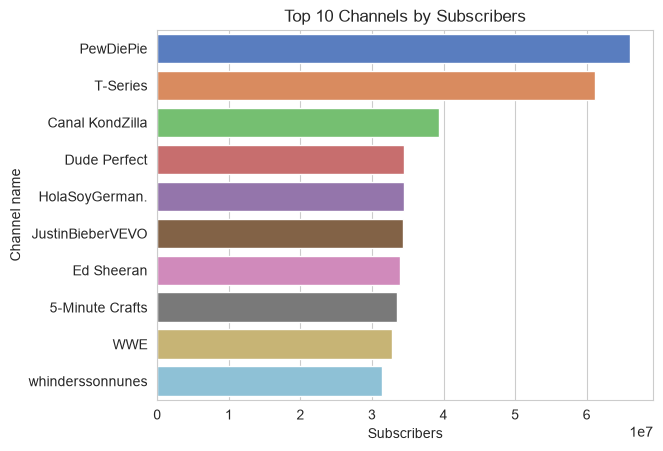

In [51]:
# convert Subscribers to numeric (handle commas / non-numeric) and select top 10 without mutating df
subs = pd.to_numeric(df['Subscribers'].astype(str).str.replace(',', ''), errors='coerce')
top_channels = df.loc[subs.nlargest(10).index].copy()
top_channels['Subscribers'] = subs.loc[top_channels.index]
sns.barplot(x='Subscribers', y='Channel name', data=top_channels, palette='muted')
plt.title('Top 10 Channels by Subscribers')
plt.show()


In [54]:
df.to_csv("yt_cleaned_dataset.csv", index=False)
